BASIC INFO
Shape (rows, columns): (4601, 58)

Column data types:
 word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp          

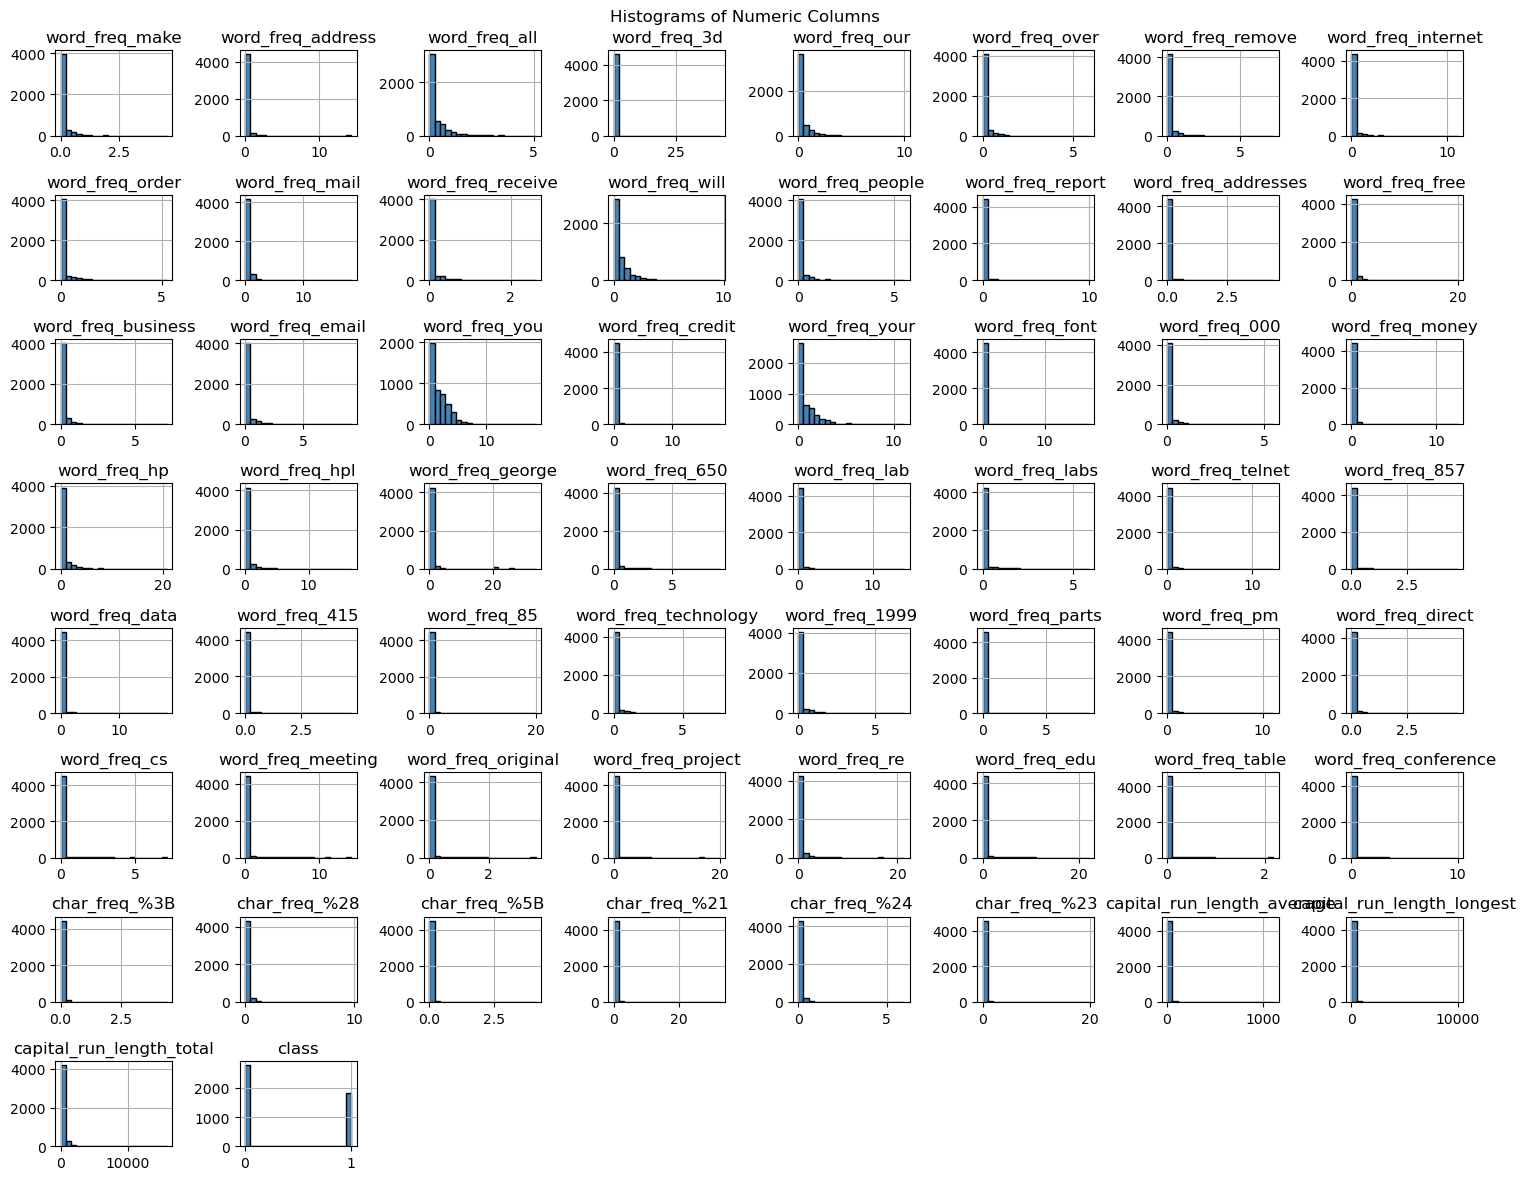

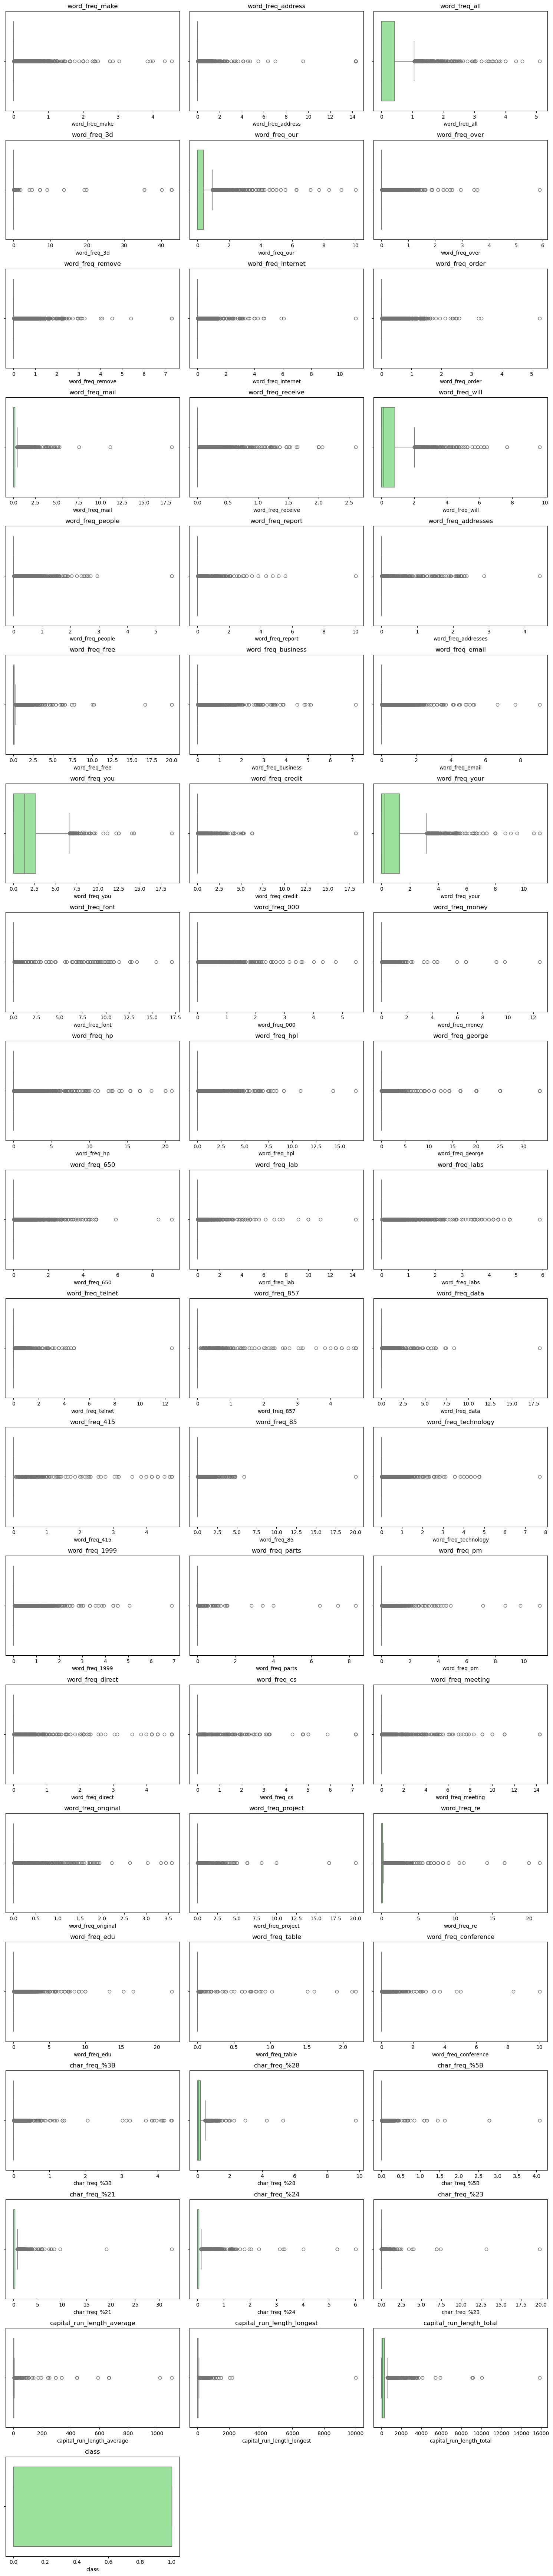

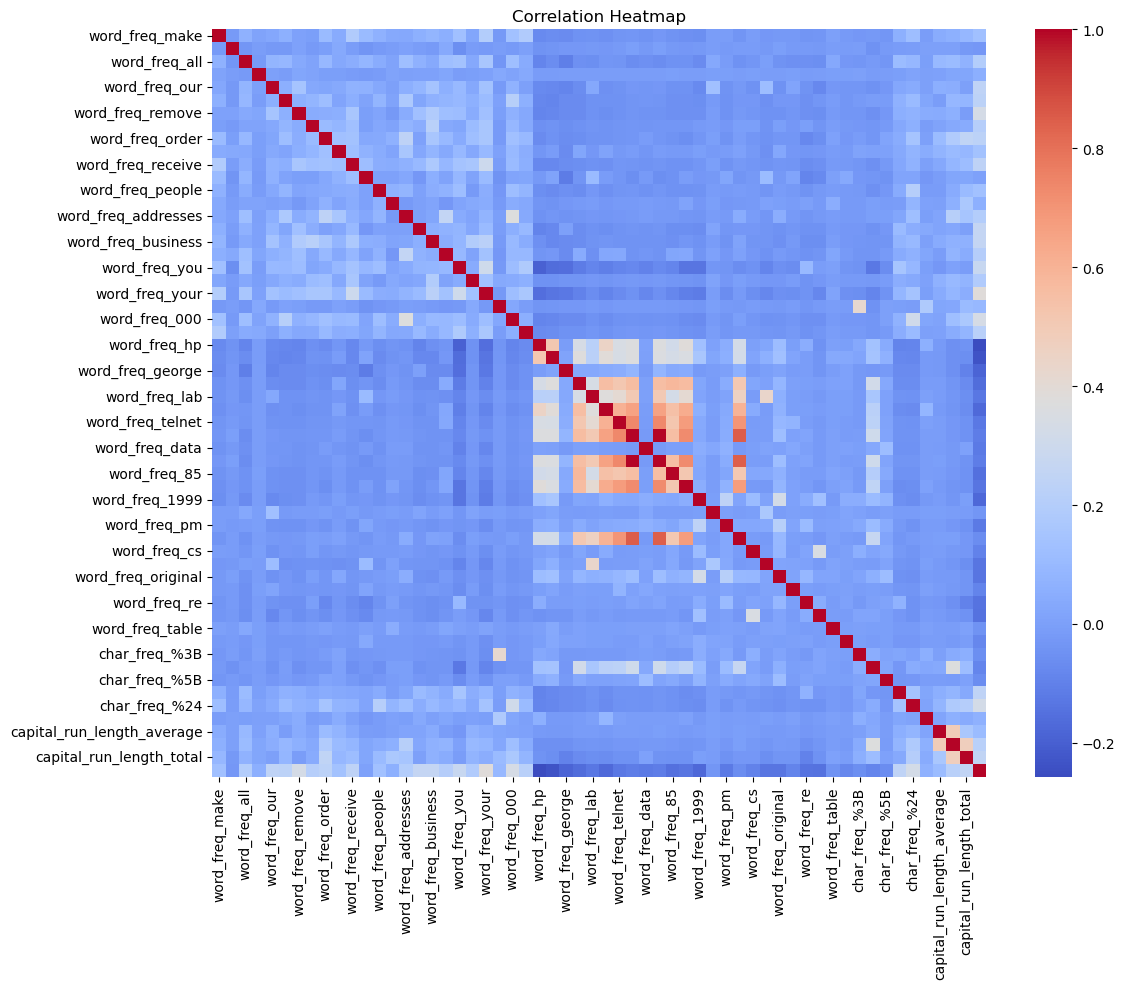

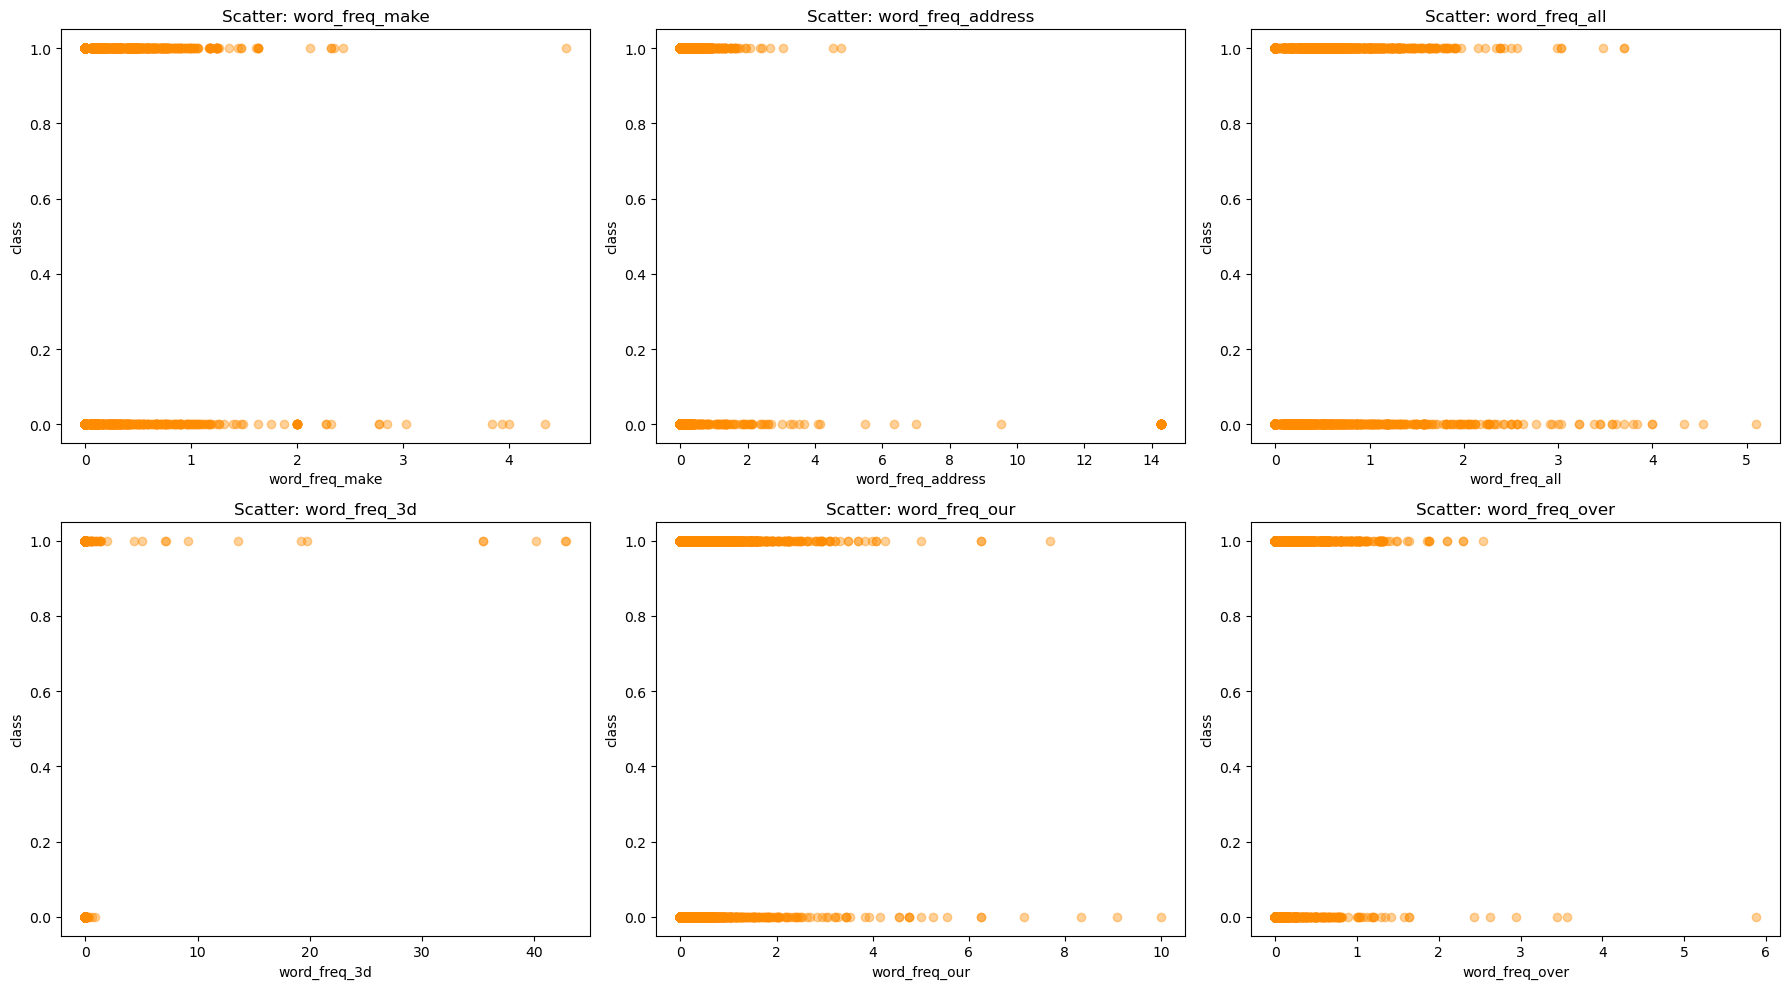


TARGET COLUMN: class
count    4601.000000
mean        0.394045
std         0.488698
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: class, dtype: float64


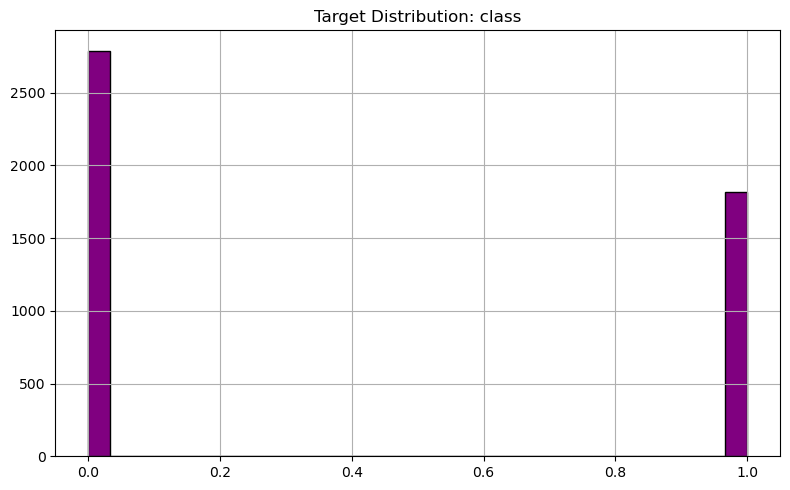


EDA complete. Plots saved as PNG files in the current folder.


In [29]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def run_eda(df, target_column=None):

    # -----------------------------------------------------
    # 1. Basic info
    # -----------------------------------------------------
    print("="*60)
    print("BASIC INFO")
    print("="*60)
    print("Shape (rows, columns):", df.shape)
    print("\nColumn data types:\n", df.dtypes)
    print("\nFirst 5 rows:\n", df.head())

    # -----------------------------------------------------
    # 2. Missing values
    # -----------------------------------------------------
    print("\n" + "="*60)
    print("MISSING VALUES")
    print("="*60)
    missing = df.isnull().sum()
    print(missing[missing > 0])
    if missing.sum() == 0:
        print("No missing values found.")

    # -----------------------------------------------------
    # 3. Separate numeric and categorical columns
    # -----------------------------------------------------
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(include="object").columns.tolist()

    print("\nNumeric columns:", numeric_cols)
    print("Categorical columns:", categorical_cols)

    # -----------------------------------------------------
    # 4. Summary statistics
    # -----------------------------------------------------
    print("\n" + "="*60)
    print("SUMMARY STATISTICS (numeric columns)")
    print("="*60)
    if numeric_cols:
        print(df[numeric_cols].describe())
    else:
        print("No numeric columns found.")

    print("\n" + "="*60)
    print("SUMMARY STATISTICS (categorical columns)")
    print("="*60)
    if categorical_cols:
        print(df[categorical_cols].describe())
    else:
        print("No categorical columns found.")

    # -----------------------------------------------------
    # 5. Skewness of numeric columns
    # -----------------------------------------------------
    if numeric_cols:
        print("\n" + "="*60)
        print("SKEWNESS (numeric columns)")
        print("="*60)
        print(df[numeric_cols].skew())

    # -----------------------------------------------------
    # 6. Histograms for numeric columns
    # -----------------------------------------------------
    if numeric_cols:
        df[numeric_cols].hist(figsize=(15, 12), bins=20, color="steelblue", edgecolor="black")
        plt.suptitle("Histograms of Numeric Columns")
        plt.tight_layout()
        plt.savefig("eda_histograms.png")
        plt.show()

    # -----------------------------------------------------
    # 7. Boxplots for numeric columns (outlier check)
    # -----------------------------------------------------
    if numeric_cols:
        n_cols = len(numeric_cols)
        plt.figure(figsize=(15, n_cols * 1.2))
        for i, col in enumerate(numeric_cols, 1):
            plt.subplot((n_cols // 3) + 1, 3, i)
            sns.boxplot(x=df[col], color="lightgreen")
            plt.title(col)
        plt.tight_layout()
        plt.savefig("eda_boxplots.png")
        plt.show()

    # -----------------------------------------------------
    # 8. Correlation heatmap (numeric columns only)
    # -----------------------------------------------------
    if len(numeric_cols) > 1:
        plt.figure(figsize=(12, 10))
        sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.savefig("eda_correlation_heatmap.png")
        plt.show()

    # -----------------------------------------------------
    # 9. Scatter plots (feature vs target, or feature vs index if no target)
    # -----------------------------------------------------
    if numeric_cols:
        scatter_features = numeric_cols[:6]  # limit to first 6 to keep plot readable

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        for i, col in enumerate(scatter_features):
            if target_column is not None and target_column in df.columns and target_column in numeric_cols:
                axes[i].scatter(df[col], df[target_column], alpha=0.4, color="darkorange")
                axes[i].set_ylabel(target_column)
            else:
                axes[i].scatter(df.index, df[col], alpha=0.4, color="darkorange")
                axes[i].set_ylabel(col)
            axes[i].set_xlabel(col)
            axes[i].set_title(f"Scatter: {col}")

        plt.tight_layout()
        plt.savefig("eda_scatterplots.png")
        plt.show()

    # -----------------------------------------------------
    # 10. Bar plots for categorical columns (value counts)
    # -----------------------------------------------------
    for col in categorical_cols:
        plt.figure(figsize=(8, 4))
        df[col].value_counts().head(15).plot(kind="bar", color="salmon")
        plt.title(f"Value Counts: {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        safe_name = col.replace(" ", "_")
        plt.savefig(f"eda_barplot_{safe_name}.png")
        plt.show()

    # -----------------------------------------------------
    # 11. Target column distribution (if provided)
    # -----------------------------------------------------
    if target_column is not None and target_column in df.columns:
        print("\n" + "="*60)
        print(f"TARGET COLUMN: {target_column}")
        print("="*60)
        print(df[target_column].describe())

        plt.figure(figsize=(8, 5))
        if target_column in numeric_cols:
            df[target_column].hist(bins=30, color="purple", edgecolor="black")
        else:
            df[target_column].value_counts().plot(kind="bar", color="purple")
        plt.title(f"Target Distribution: {target_column}")
        plt.tight_layout()
        plt.savefig("eda_target_distribution.png")
        plt.show()

    print("\nEDA complete. Plots saved as PNG files in the current folder.")


# ---------------------------------------------------------
# Example usage
# ---------------------------------------------------------
if __name__ == "__main__":
    df = pd.read_csv(r"C:\Users\SSN\Downloads\archive(6)\spambase_csv.csv")
    run_eda(df, target_column="class")

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.naive_bayes import BernoulliNB, MultinomialNB, GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt


target = "class"

df = pd.read_csv(r"C:\Users\SSN\Downloads\archive(6)\spambase_csv.csv")
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
X_raw = df.drop(columns=[target])
y = df[target]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps spam/ham ratio consistent in both splits
)

print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (3680, 57)
Test shape: (921, 57)
Train class balance:
 class
0    0.605978
1    0.394022
Name: proportion, dtype: float64
Test class balance:
 class
0    0.605863
1    0.394137
Name: proportion, dtype: float64


In [4]:
from sklearn.naive_bayes import GaussianNB

k_values = [10, 15, 20, 30, 45, 57]
k_results = []

for k_test in k_values:
    sel = SelectKBest(
        score_func=chi2, 
        k=k_test
    )
    sel.fit(X_train_raw, y_train)
    feats = X_train_raw.columns[sel.get_support()].tolist()

    Xtr = np.log1p(X_train_raw[feats])
    skf_k = StratifiedKFold(
        n_splits=5, 
        shuffle=True, 
        random_state=42
    )
    scores = cross_val_score(
        GaussianNB(), 
        Xtr, 
        y_train, 
        cv=skf_k, 
        scoring='f1'
    )

    k_results.append({"k": k_test, "Mean F1": scores.mean(), "Std": scores.std()})

k_df = pd.DataFrame(k_results)
print(k_df)

best_k = k_df.loc[k_df["Mean F1"].idxmax(), "k"]
print(f"\nBest k: {best_k}")

    k   Mean F1       Std
0  10  0.859211  0.020249
1  15  0.876940  0.011874
2  20  0.911770  0.004951
3  30  0.888154  0.010728
4  45  0.804767  0.008371
5  57  0.810313  0.012150

Best k: 20


In [5]:
selector = SelectKBest(
    score_func=chi2, 
    k=best_k
)
selector.fit(X_train_raw, y_train) 
selected_features = X_train_raw.columns[selector.get_support()].tolist()
chi2_scores = pd.DataFrame({
    'Feature': X_train_raw.columns,
    'Chi2_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values(by='Chi2_Score', ascending=False).reset_index(drop=True)

print("Selected Features")
print(chi2_scores.head(best_k))
print("\nSelected features:", selected_features)

X_train_sel = X_train_raw[selected_features].copy()
X_test_sel = X_test_raw[selected_features].copy()

Selected Features
                       Feature     Chi2_Score        P_Value
0     capital_run_length_total  276446.949698   0.000000e+00
1   capital_run_length_longest  127794.527152   0.000000e+00
2   capital_run_length_average    9371.985727   0.000000e+00
3             word_freq_george    1821.847824   0.000000e+00
4                 word_freq_hp    1241.364742  6.247590e-272
5               word_freq_your     996.112148  1.257032e-218
6               word_freq_free     659.075283  2.373760e-145
7                word_freq_hpl     598.189829  4.145020e-132
8             word_freq_remove     550.290175  1.088593e-121
9                word_freq_000     510.068871  6.126752e-113
10               word_freq_you     496.931119  4.422838e-110
11               char_freq_%21     483.416991  3.856731e-107
12            word_freq_credit     432.935846   3.731697e-96
13                word_freq_3d     383.736756   1.911706e-85
14          word_freq_business     366.056421   1.351592e-81
15    

In [6]:
skew_before = X_train_sel.skew().sort_values(ascending=False)
print("Skewness of selected features (train set, BEFORE transform):")
print(skew_before)

Skewness of selected features (train set, BEFORE transform):
capital_run_length_longest    31.971596
word_freq_3d                  25.382222
capital_run_length_average    23.901030
char_freq_%21                 20.363392
word_freq_credit              14.688571
word_freq_money               12.764025
word_freq_free                11.683711
char_freq_%24                 11.522217
word_freq_edu                  9.351651
word_freq_meeting              9.033802
capital_run_length_total       9.027824
word_freq_remove               7.008064
word_freq_hpl                  6.537112
word_freq_000                  5.774432
word_freq_george               5.736088
word_freq_business             5.735952
word_freq_hp                   5.698861
word_freq_our                  4.458956
word_freq_your                 2.346151
word_freq_you                  1.610799
dtype: float64


In [7]:
X_train_log = np.log1p(X_train_sel)
X_test_log = np.log1p(X_test_sel)
skew_after = X_train_log.skew()
skew_compare = pd.DataFrame({
    'Skew_Before': skew_before[selected_features],
    'Skew_After': skew_after[selected_features],
})
print("Skewness comparison — Before vs After log1p:")
print(skew_compare)

Skewness comparison — Before vs After log1p:
                            Skew_Before  Skew_After
word_freq_3d                  25.382222   17.650254
word_freq_our                  4.458956    1.967006
word_freq_remove               7.008064    3.652099
word_freq_free                11.683711    3.098847
word_freq_business             5.735952    3.306358
word_freq_you                  1.610799    0.167650
word_freq_credit              14.688571    5.821506
word_freq_your                 2.346151    0.889274
word_freq_000                  5.774432    3.621566
word_freq_money               12.764025    4.887769
word_freq_hp                   5.698861    2.416520
word_freq_hpl                  6.537112    3.046564
word_freq_george               5.736088    3.635988
word_freq_meeting              9.033802    5.209272
word_freq_edu                  9.351651    4.811465
char_freq_%21                 20.363392    2.912824
char_freq_%24                 11.522217    4.793582
capital_run_length_

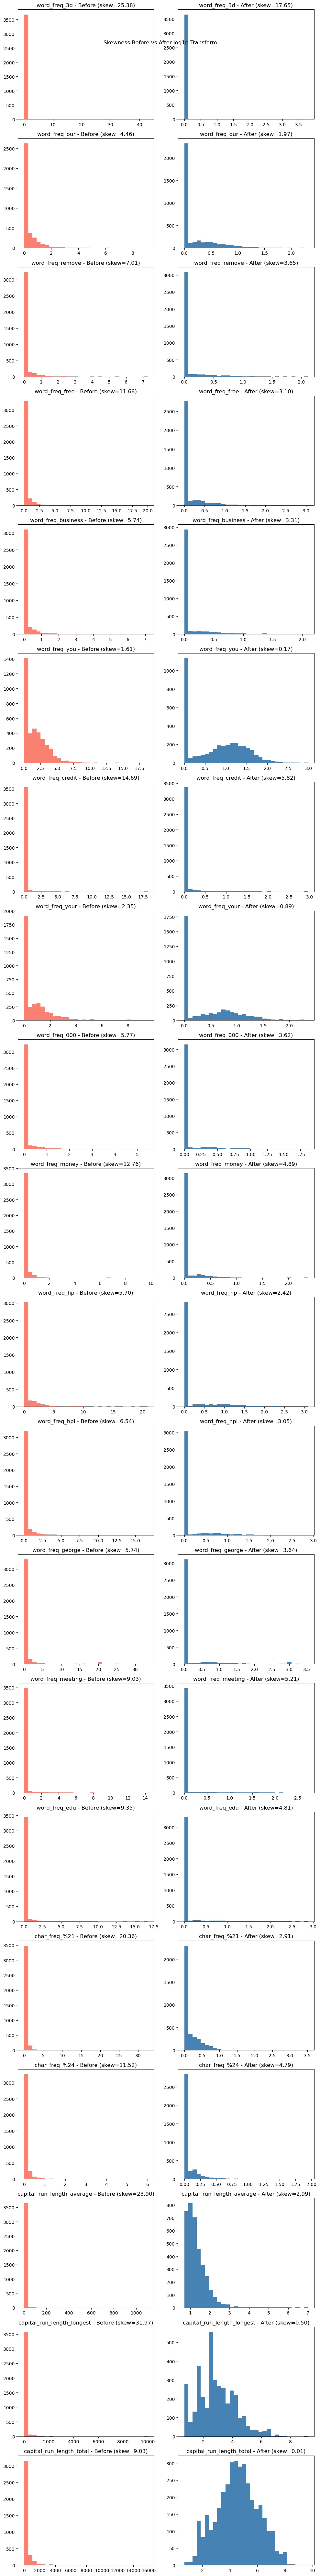

In [8]:
n_features = len(selected_features)

fig, axes = plt.subplots(n_features, 2, figsize=(10, 4 * n_features))

for i, feat in enumerate(selected_features):
    axes[i, 0].hist(X_train_sel[feat], bins=30, color='salmon')
    axes[i, 0].set_title(f"{feat} - Before (skew={skew_before[feat]:.2f})")

    axes[i, 1].hist(X_train_log[feat], bins=30, color='steelblue')
    axes[i, 1].set_title(f"{feat} - After (skew={skew_after[feat]:.2f})")

plt.suptitle("Skewness Before vs After log1p Transform")
plt.tight_layout()
plt.savefig("skew_before_after_grid.png")
plt.show()

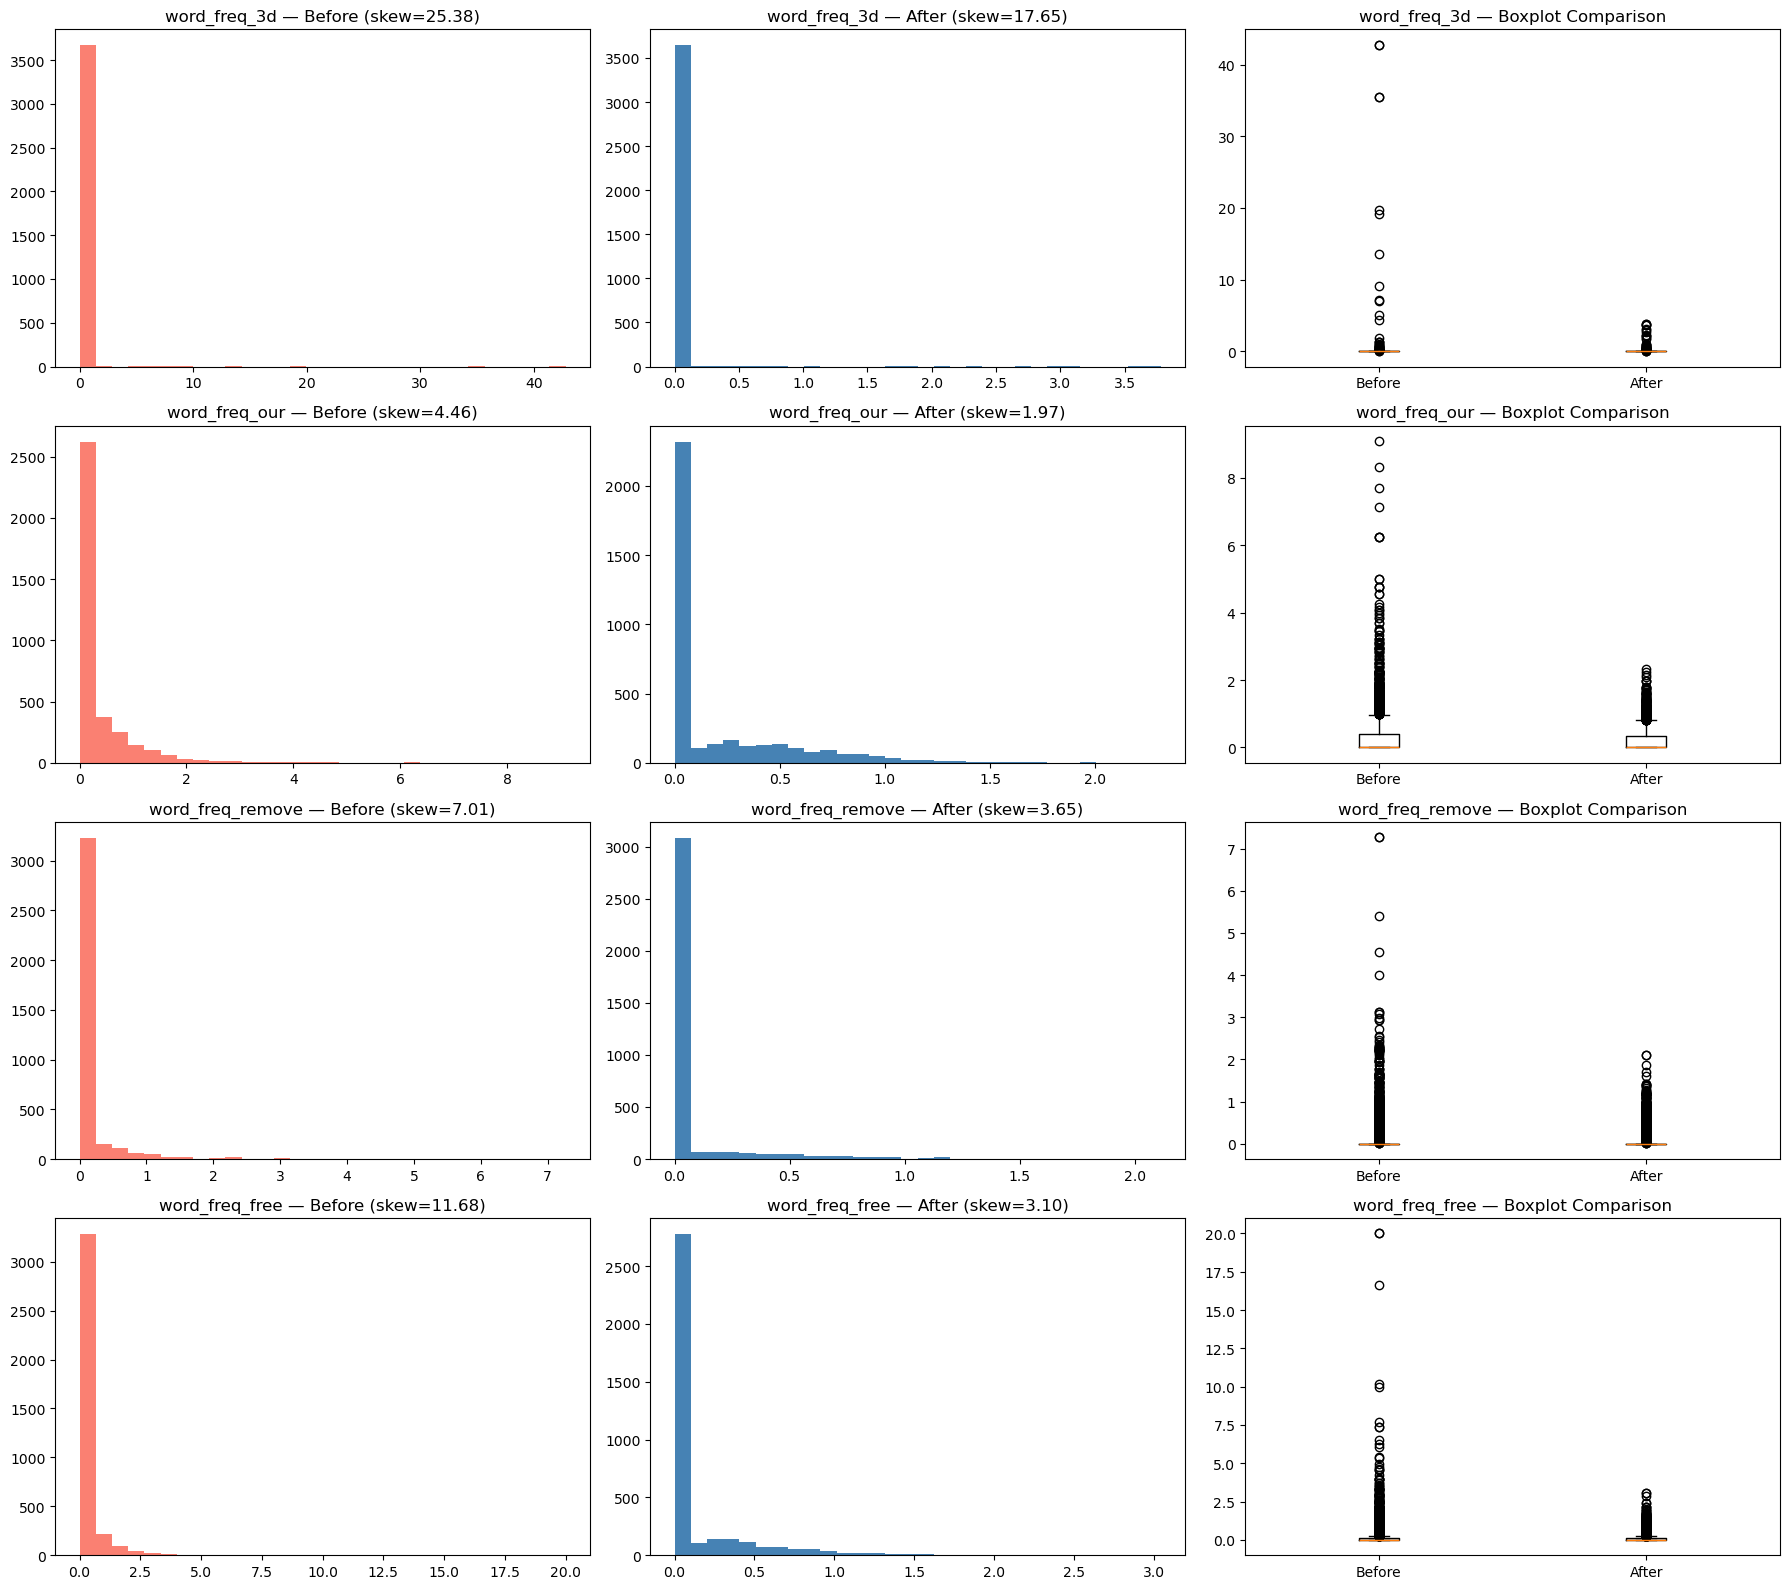

In [9]:
top4 = skew_compare.head(4).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for i, feat in enumerate(top4):
    axes[i, 0].hist(X_train_sel[feat], bins=30, color='salmon')
    axes[i, 0].set_title(f"{feat} — Before (skew={skew_before[feat]:.2f})")

    axes[i, 1].hist(X_train_log[feat], bins=30, color='steelblue')
    axes[i, 1].set_title(f"{feat} — After (skew={skew_after[feat]:.2f})")

    axes[i, 2].boxplot([X_train_sel[feat], X_train_log[feat]], tick_labels=['Before', 'After'])
    axes[i, 2].set_title(f"{feat} — Boxplot Comparison")

plt.tight_layout()
plt.savefig("skew_top4_detailed.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold


param_grid = {'var_smoothing': np.logspace(-9, -1, 50)}
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    GaussianNB(), 
    param_grid, 
    scoring='f1', 
    cv=skf, 
    n_jobs=-1
)
grid.fit(X_train_log, y_train)
print("GridSearchCV best var_smoothing:", grid.best_params_, "F1:", grid.best_score_)

rand = RandomizedSearchCV(
    GaussianNB(), 
    param_grid, 
    scoring='f1', 
    cv=skf,
    n_iter=20, 
    random_state=42, 
    n_jobs=-1
)
rand.fit(X_train_log, y_train)
print("RandomizedSearchCV best var_smoothing:", rand.best_params_, "F1:", rand.best_score_)

best_gnb = grid.best_estimator_ #or rand

GridSearchCV best var_smoothing: {'var_smoothing': 1e-09} F1: 0.911770411272762
RandomizedSearchCV best var_smoothing: {'var_smoothing': 1.3257113655901082e-07} F1: 0.911770411272762


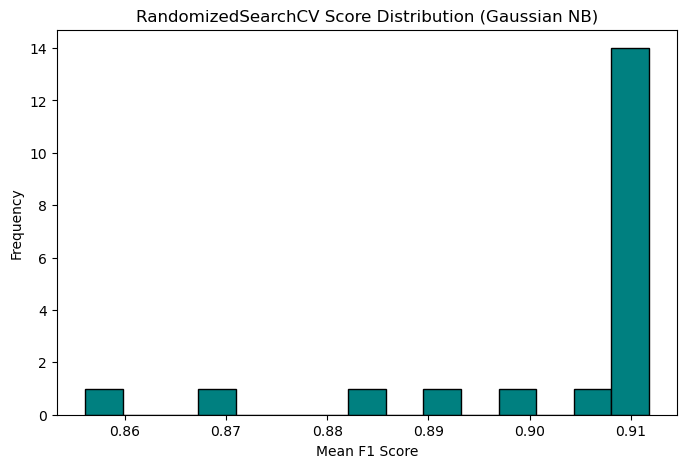

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(rand.cv_results_['mean_test_score'], bins=15, color='teal', edgecolor='black')
plt.xlabel("Mean F1 Score")
plt.ylabel("Frequency")
plt.title("RandomizedSearchCV Score Distribution (Gaussian NB)")
plt.show()

In [11]:

param_grid_bnb = {'alpha': np.logspace(-3, 1, 30)}

grid_bnb = GridSearchCV(
    BernoulliNB(binarize=0.0), 
    param_grid_bnb, 
    scoring='f1', 
    cv=skf, 
    n_jobs=-1
)
grid_bnb.fit(X_train_log, y_train)
print("Bernoulli GridSearchCV best alpha:", grid_bnb.best_params_, "F1:", grid_bnb.best_score_)

rand_bnb = RandomizedSearchCV(
    BernoulliNB(binarize=0.0), 
    param_grid_bnb, 
    scoring='f1', 
    cv=skf,
    n_iter=20, 
    random_state=42, 
    n_jobs=-1
)
rand_bnb.fit(X_train_log, y_train)
print("Bernoulli RandomizedSearchCV best alpha:", rand_bnb.best_params_, "F1:", rand_bnb.best_score_)

best_bnb = grid_bnb.best_estimator_ if grid_bnb.best_score_ >= rand_bnb.best_score_ else rand_bnb.best_estimator_

# Multinomial NB - alpha controls Laplace smoothing
param_grid_mnb = {'alpha': np.logspace(-3, 1, 30)}

grid_mnb = GridSearchCV(
    MultinomialNB(), 
    param_grid_mnb, 
    scoring='f1', 
    cv=skf, 
    n_jobs=-1
)
grid_mnb.fit(X_train_log, y_train)
print("Multinomial GridSearchCV best alpha:", grid_mnb.best_params_, "F1:", grid_mnb.best_score_)

rand_mnb = RandomizedSearchCV(
    MultinomialNB(), 
    param_grid_mnb, 
    scoring='f1', 
    cv=skf,
    n_iter=20, 
    random_state=42, 
    n_jobs=-1
)
rand_mnb.fit(X_train_log, y_train)
print("Multinomial RandomizedSearchCV best alpha:", rand_mnb.best_params_, "F1:", rand_mnb.best_score_)

best_mnb = grid_mnb.best_estimator_ if grid_mnb.best_score_ >= rand_mnb.best_score_ else rand_mnb.best_estimator_

Bernoulli GridSearchCV best alpha: {'alpha': 0.001} F1: 0.8668668983552749
Bernoulli RandomizedSearchCV best alpha: {'alpha': 0.11721022975334805} F1: 0.8668668983552749
Multinomial GridSearchCV best alpha: {'alpha': 10.0} F1: 0.8808446744330338
Multinomial RandomizedSearchCV best alpha: {'alpha': 7.278953843983146} F1: 0.8802649543332552


In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

def best_f1_threshold(model, X, y, cv):
    y_proba_cv = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y, y_proba_cv)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
    idx = np.argmax(f1_scores[:-1])
    return thresholds[idx], f1_scores[idx], thresholds, f1_scores[:-1]

best_threshold, gnb_thresh_f1, gnb_thresholds, gnb_f1_curve = best_f1_threshold(best_gnb, X_train_log, y_train, skf)
best_threshold_bnb, bnb_thresh_f1, bnb_thresholds, bnb_f1_curve = best_f1_threshold(best_bnb, X_train_log, y_train, skf)
best_threshold_mnb, mnb_thresh_f1, mnb_thresholds, mnb_f1_curve = best_f1_threshold(best_mnb, X_train_log, y_train, skf)

print(f"Gaussian NB — best threshold:{best_threshold:.3f},F1: {gnb_thresh_f1:.4f}")
print(f"Bernoulli NB — best threshold:{best_threshold_bnb:.3f},F1: {bnb_thresh_f1:.4f}")
print(f"Multinomial NB — best threshold:{best_threshold_mnb:.3f},F1: {mnb_thresh_f1:.4f}")



Gaussian NB — best threshold:0.529,F1: 0.9127
Bernoulli NB — best threshold:0.081,F1: 0.8711
Multinomial NB — best threshold:0.599,F1: 0.8954


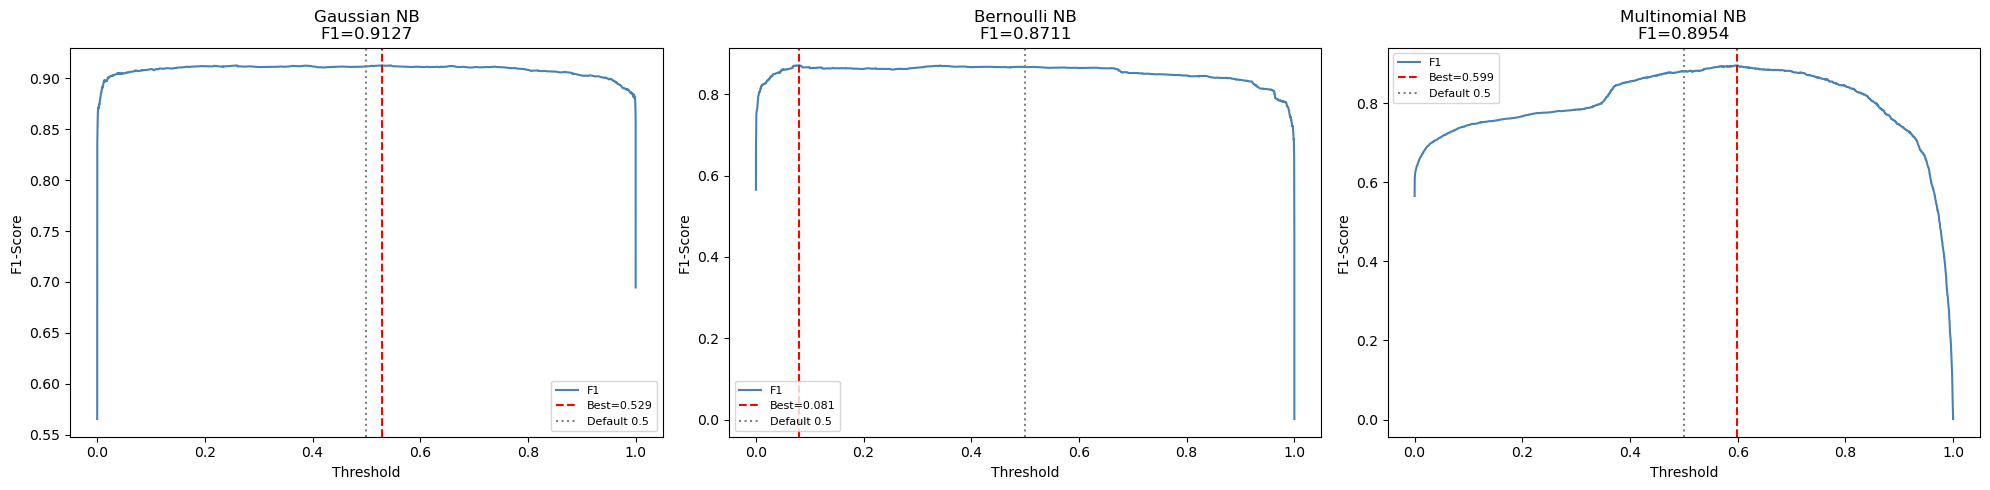

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

curves = [
    ("Gaussian NB", gnb_thresholds, gnb_f1_curve, best_threshold, gnb_thresh_f1),
    ("Bernoulli NB", bnb_thresholds, bnb_f1_curve, best_threshold_bnb, bnb_thresh_f1),
    ("Multinomial NB", mnb_thresholds, mnb_f1_curve, best_threshold_mnb, mnb_thresh_f1),
]

for ax, (name, thresholds, f1_curve, best_t, best_f1) in zip(axes, curves):
    ax.plot(thresholds, f1_curve, label='F1', color='steelblue')
    ax.axvline(best_t, color='red', linestyle='--', label=f'Best={best_t:.3f}')
    ax.axvline(0.5, color='gray', linestyle=':', label='Default 0.5')
    ax.set_title(f"{name}\nF1={best_f1:.4f}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F1-Score")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("threshold_tuning_all_models.png", dpi=200, bbox_inches='tight')
plt.show()

In [14]:


models = {
    "Bernoulli NB": best_bnb,
    "Multinomial NB": best_mnb,
    "Gaussian NB": best_gnb
}

threshold_map = {
    "Bernoulli NB": best_threshold_bnb,
    "Multinomial NB": best_threshold_mnb,
    "Gaussian NB": best_threshold
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_log, y_train, cv=skf, scoring='f1')
    cv_results[name] = scores
    print(f"{name}: Mean F1={scores.mean():.4f}, Std={scores.std():.4f}")

Bernoulli NB: Mean F1=0.8669, Std=0.0099
Multinomial NB: Mean F1=0.8808, Std=0.0095
Gaussian NB: Mean F1=0.9118, Std=0.0050


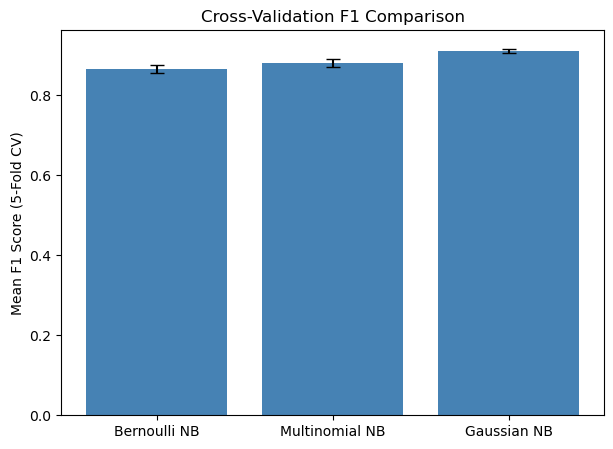

In [23]:
cv_means = {name: scores.mean() for name, scores in cv_results.items()}
cv_stds = {name: scores.std() for name, scores in cv_results.items()}

plt.figure(figsize=(7, 5))
plt.bar(cv_means.keys(), cv_means.values(), yerr=list(cv_stds.values()), color='steelblue', capsize=5)
plt.ylabel("Mean F1 Score (5-Fold CV)")
plt.title("Cross-Validation F1 Comparison")
plt.show()

In [15]:
summary = []

for name, scores in cv_results.items():
    summary.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Average": scores.mean(),
        "Std Dev": scores.std()
    })

summary_df = pd.DataFrame(summary).round(4)

print(summary_df)

            Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Average  Std Dev
0    Bernoulli NB  0.8813  0.8714  0.8510  0.8642  0.8664   0.8669   0.0099
1  Multinomial NB  0.8885  0.8742  0.8947  0.8687  0.8780   0.8808   0.0095
2     Gaussian NB  0.9183  0.9155  0.9078  0.9047  0.9125   0.9118   0.0050


In [16]:
results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_log, y_train)
    fitted_models[name] = model
    y_prob = model.predict_proba(X_test_log)[:, 1]

    y_pred = (y_prob >= threshold_map[name]).astype(int)

    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"] * 100,
        "Precision": report["1"]["precision"] * 100,
        "Recall": report["1"]["recall"] * 100,
        "F1-Score": report["1"]["f1-score"] * 100,
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison = pd.DataFrame(results).round(2)
print(comparison)

            Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0    Bernoulli NB     88.38      81.68   90.91     86.05     0.95
1  Multinomial NB     91.64      88.44   90.63     89.52     0.96
2     Gaussian NB     92.62      90.19   91.18     90.68     0.97


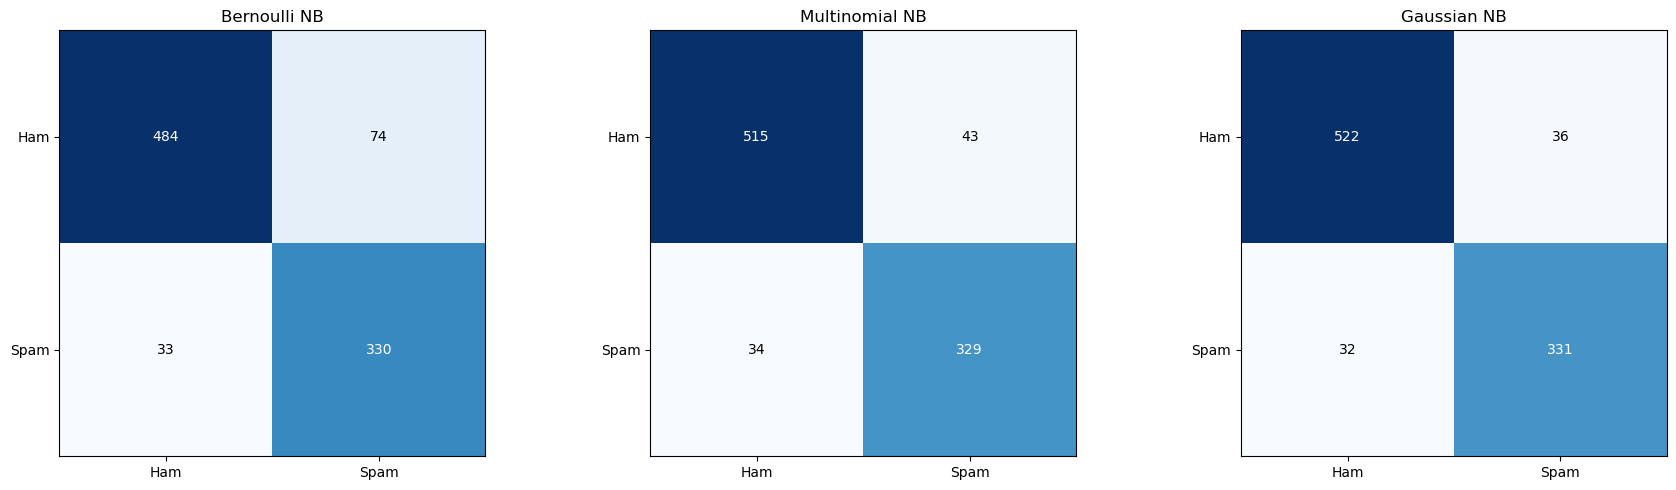

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, fitted_models.items()):
    y_prob = model.predict_proba(X_test_log)[:, 1]
    y_pred = (y_prob >= threshold_map[name]).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Ham", "Spam"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Ham", "Spam"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.savefig("confusion_matrices_all.png", dpi=200, bbox_inches='tight')
plt.show()

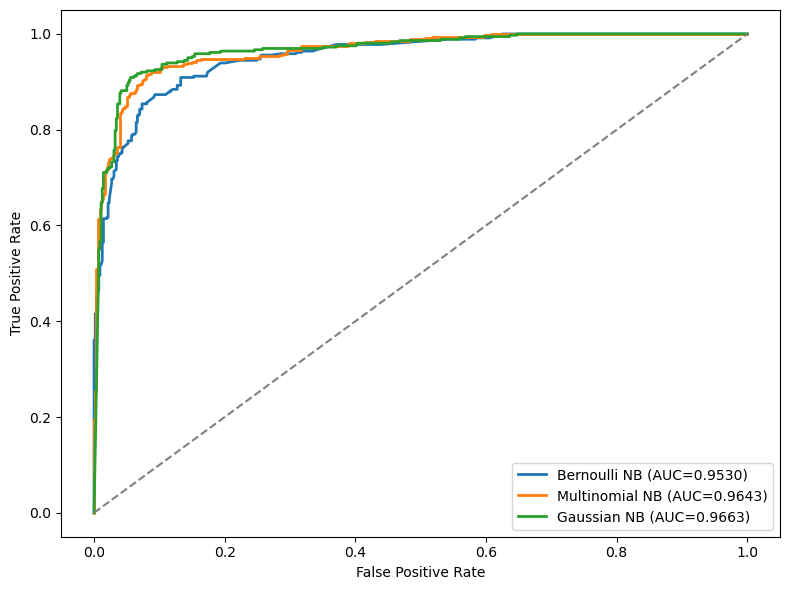

In [18]:
plt.figure(figsize=(8, 6))
for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test_log)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

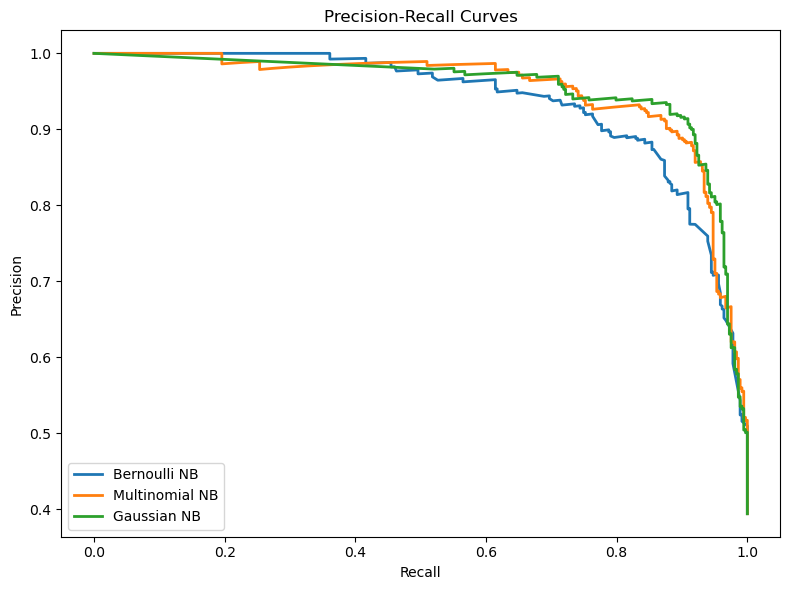

In [24]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))
for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test_log)[:, 1]
    precisions, recalls, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recalls, precisions, lw=2, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
comparison_ranked = comparison.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
best_model_name = comparison_ranked.iloc[0]["Model"]
print(comparison_ranked)
print(f"Best Model: {best_model_name}")

            Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0     Gaussian NB     92.62      90.19   91.18     90.68     0.97
1  Multinomial NB     91.64      88.44   90.63     89.52     0.96
2    Bernoulli NB     88.38      81.68   90.91     86.05     0.95
Best Model: Gaussian NB


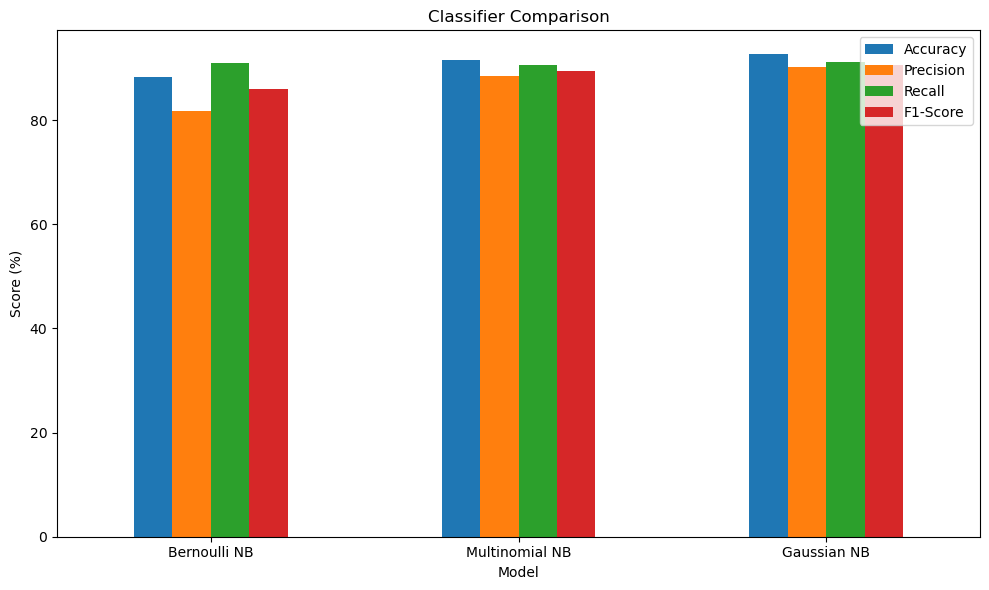

In [25]:
comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.ylabel("Score (%)")
plt.title("Classifier Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
print(f"Dataset: Spambase ({df.shape[0]} rows, {len(selected_features)} features)")
print(f"Selection metric: F1-Score (spam class)")
print(f"Best model: {best_model_name}")
print(comparison_ranked.to_string(index=False))

Dataset: Spambase (4601 rows, 20 features)
Selection metric: F1-Score (spam class)
Best model: Gaussian NB
         Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
   Gaussian NB     92.62      90.19   91.18     90.68     0.97
Multinomial NB     91.64      88.44   90.63     89.52     0.96
  Bernoulli NB     88.38      81.68   90.91     86.05     0.95


KNN

In [21]:
import time
import pandas as pd

models = {
    "Bernoulli NB": best_bnb,
    "Multinomial NB": best_mnb,
    "Gaussian NB": best_gnb
}

time_results = []

for name, model in models.items():

    # Training time
    start = time.perf_counter()
    model.fit(X_train_log, y_train)
    train_time = time.perf_counter() - start

    # Prediction time
    start = time.perf_counter()
    model.predict(X_test_log)
    prediction_time = time.perf_counter() - start

    time_results.append({
        "Model": name,
        "Training Time (s)": train_time,
        "Prediction Time (s)": prediction_time
    })

time_df = pd.DataFrame(time_results)

# Display up to 6 decimal places
print(time_df.round(6))

            Model  Training Time (s)  Prediction Time (s)
0    Bernoulli NB           0.011713             0.005278
1  Multinomial NB           0.006668             0.002727
2     Gaussian NB           0.008250             0.003486


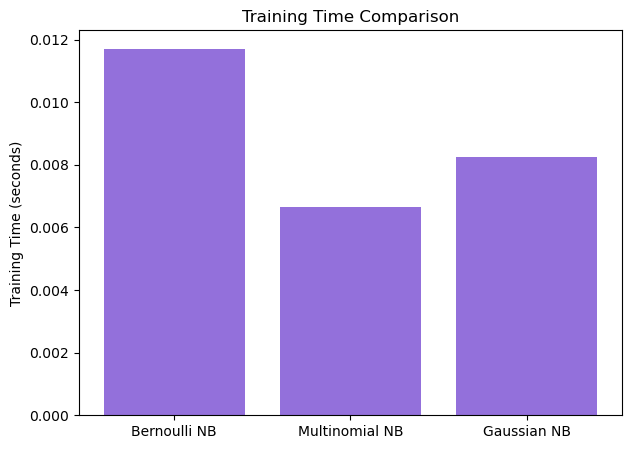

In [26]:
plt.figure(figsize=(7, 5))
plt.bar(time_df["Model"], time_df["Training Time (s)"], color='mediumpurple')
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.show()

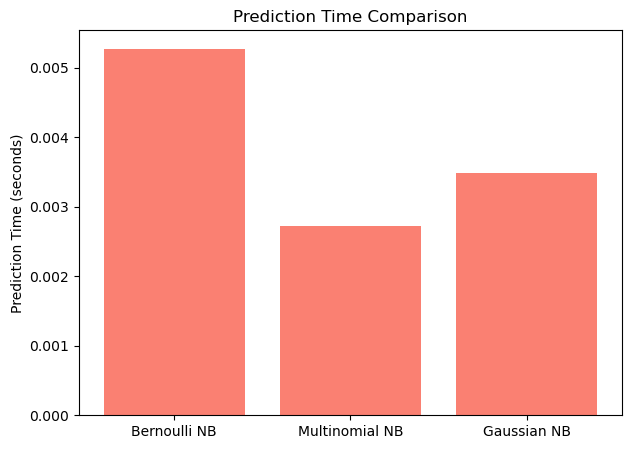

In [27]:
plt.figure(figsize=(7, 5))
plt.bar(time_df["Model"], time_df["Prediction Time (s)"], color='salmon')
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time Comparison")
plt.show()